In [1]:
import os
os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-103d0467-6f6b-4e3d-85b9-6ff54b61a126"
os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-28549a32-72c0-42d3-a0e9-da2162af9b08"
os.environ["LANGFUSE_HOST"] = "https://langfuse-orcha.web.cern.ch"

from requests.auth import HTTPBasicAuth
import requests


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


HOST = os.environ.get("LANGFUSE_HOST", "https://cloud.langfuse.com")
PUBLIC_KEY = os.environ["LANGFUSE_PUBLIC_KEY"]
SECRET_KEY = os.environ["LANGFUSE_SECRET_KEY"]

AUTH = HTTPBasicAuth(PUBLIC_KEY, SECRET_KEY)


/Users/juliehinge/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Get all experiments/runs for a dataset


In [2]:
# First get the overall dataset
DATASET_NAME = "dataset"
def list_dataset_runs(dataset_name: str):
    runs = []
    page = 1

    while True:
        resp = requests.get(
            f"{HOST}/api/public/datasets/{dataset_name}/runs",
            auth=AUTH,
            params={
                "page": page,
                "limit": 50,
            },
        )
        resp.raise_for_status()

        data = resp.json()
        runs.extend(data.get("data", []))

        meta = data.get("meta", {})

        if page >= meta.get("totalPages", page):
            break

        page += 1

    return runs

# Get all experiments under the dataset
def get_run_detail(dataset_name: str, run_name: str):
    resp = requests.get(
        f"{HOST}/api/public/datasets/{dataset_name}/runs/{run_name}",
        auth=AUTH,
    )
    resp.raise_for_status()
    return resp.json()

def get_dataset_experiments(dataset_name: str):
    runs = list_dataset_runs(dataset_name)

    return {
        run["name"].split(" - ")[0]: get_run_detail(
            dataset_name,
            run["name"],
        )
        for run in runs
    }

experiments = get_dataset_experiments(DATASET_NAME)


### Get all traces and their associated scores + latencies 

In [3]:
def get_trace(trace_id: str):
    resp = requests.get(
        f"{HOST}/api/public/traces/{trace_id}",
        auth=AUTH, 
    )

    if resp.status_code in (404, 422):
        return None, resp.status_code

    resp.raise_for_status()

    return resp.json(), 200


# Extract scores and latency from every trace for every experiment
def format_trace(trace):

    scores = {
        score["name"]: score["value"]
        for score in trace.get("scores", [])
    }

    latency = trace.get("latency")

    return scores, latency


all_results = []
skipped_traces = []

for experiment_name, experiment in experiments.items():

    items = experiment.get("datasetRunItems", [])

    for item in items:

        trace_id = item["traceId"]

        trace, status = get_trace(trace_id)

        if trace is None:
            skipped_traces.append({
                "experiment": experiment_name,
                "dataset_item": item["datasetItemId"],
                "trace_id": trace_id,
                "status": status,
            })
            continue

        scores, latency = format_trace(trace)

        all_results.append({
            "experiment": experiment_name,
            "dataset_item": item["datasetItemId"],
            "trace_id": trace_id,
            "latency": latency,
            "scores": scores,
        })

print(f"Collected {len(all_results)} results")
print(f"Skipped {len(skipped_traces)} traces")

Collected 1360 results
Skipped 11 traces


#### Convert scores and latencies to dataframe

In [4]:


# Convert results into a DataFrame
rows = []

for result in all_results:

    rows.append({
        "experiment": result["experiment"],
        "dataset_item": result["dataset_item"],
        "trace_id": result["trace_id"],
        "latency": result["latency"],
        **result["scores"],
    })


df = pd.DataFrame(rows)


print("\nDataFrame shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())



DataFrame shape: (1360, 15)

Columns:
['experiment', 'dataset_item', 'trace_id', 'latency', 'creators_orcid_score', 'grounded_average', 'publication_date_score', 'creators_affiliation_indexed_score', 'creators_orcid_indexed_score', 'creators_affiliation_score', 'creators_name_score', 'doi_score', 'description_score', 'item_summary', 'title_score']


In [16]:

# Whether each row has at least one missing score
df["failed"] = df.isna().any(axis=1)

# Number of failed rows per experiment
failed_by_experiment = (
    df.groupby("experiment")["failed"]
      .agg(["sum", "count"])
      .rename(columns={
          "sum": "failed",
          "count": "total"
      })
)

failed_by_experiment["failure_rate"] = (
    failed_by_experiment["failed"]
    / failed_by_experiment["total"]
)

print(failed_by_experiment)

                                         failed  total  failure_rate
experiment                                                          
litellm_gpt-oss-20b__grobid__medium          69    454      0.151982
litellm_gpt-oss-20b__pdfplumber__medium     172    453      0.379691
litellm_gpt-oss-20b__pymupdf__medium         56    453      0.123620


### Average scores per experiment

In [14]:
averages_by_experiment = (
    df
    .groupby("experiment")
    .mean(numeric_only=True)
)


print("\nAverage scores:")
display(averages_by_experiment)





Average scores:


,latency,creators_orcid_score,grounded_average,publication_date_score,creators_affiliation_indexed_score,creators_orcid_indexed_score,creators_affiliation_score,creators_name_score,doi_score,description_score,item_summary,title_score,overall_score
experiment,,,,,,,,,,,,,
litellm_gpt-oss-20b__grobid__medium,113.325793,0.225213,0.960722,0.778819,0.449311,0.208615,0.580497,0.812674,0.787013,0.676135,0.577592,0.805909,0.590178
litellm_gpt-oss-20b__pdfplumber__medium,134.765673,0.228812,0.974718,0.753376,0.454040,0.216862,0.558593,0.839570,0.854093,0.667449,0.596698,0.867942,0.603743
litellm_gpt-oss-20b__pymupdf__medium,236.010245,0.132832,0.979411,0.721354,0.488304,0.133166,0.615007,0.839958,0.891960,0.711471,0.608951,0.880754,0.602385


#### Plot of average score per field per experiment

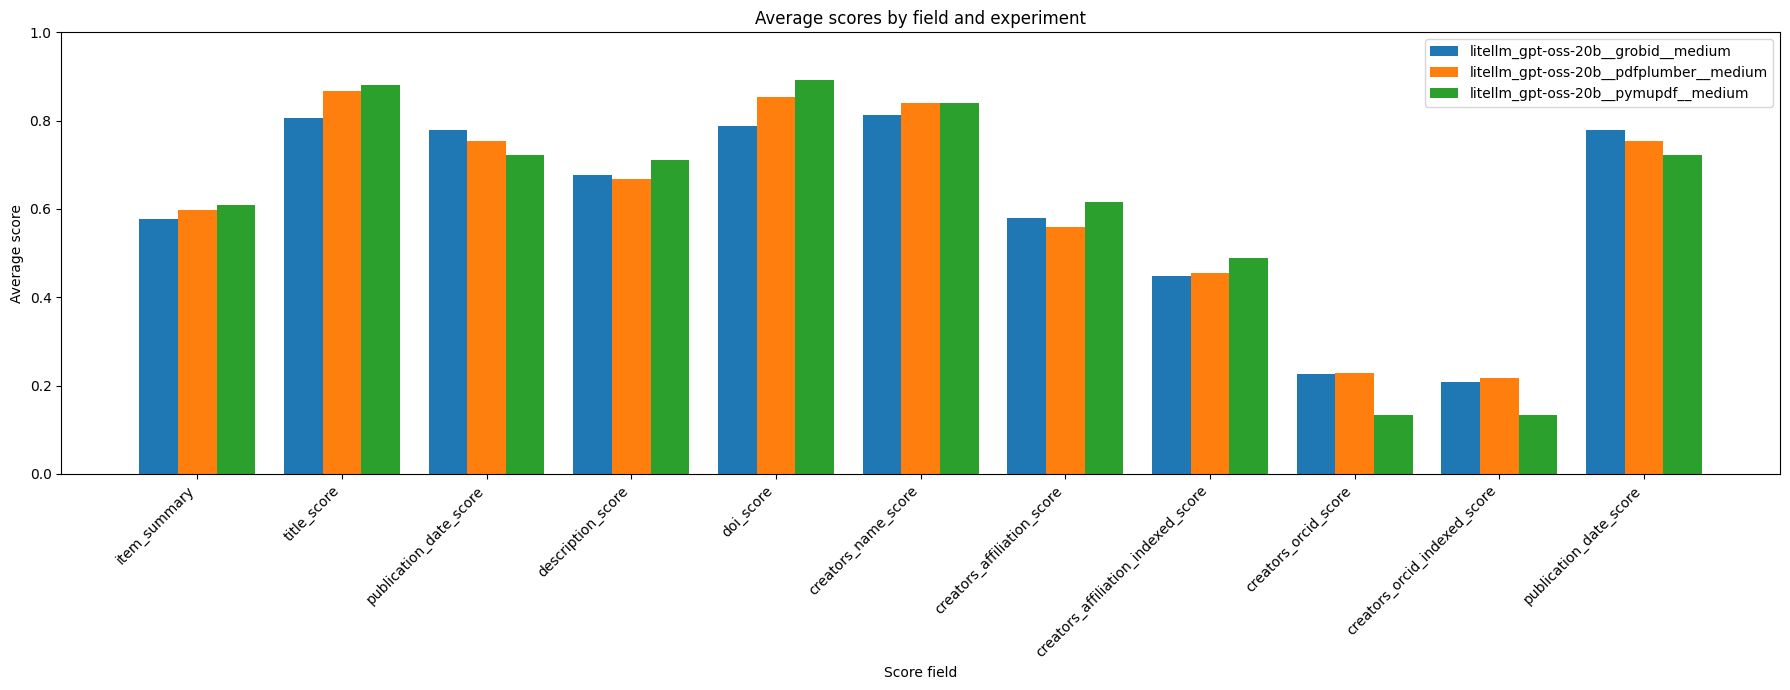

In [6]:

score_order = [
    "item_summary",
    "title_score",
    "publication_date_score",
    "description_score",
    "doi_score",
    "creators_name_score",
    "creators_affiliation_score",
    "creators_affiliation_indexed_score",
    "creators_orcid_score",
    "creators_orcid_indexed_score",
    "publication_date_score"]



plot_data = averages_by_experiment[score_order].T

# Resource types
fields = plot_data.index

# Will differ based on extractor/prompt/model
experiment_names = plot_data.columns


x = np.arange(len(fields))
width = 0.8 / len(experiment_names)
fig, ax = plt.subplots(figsize=(18, 7))


for i, experiment_name in enumerate(experiment_names):

    ax.bar(
        x + i * width,
        plot_data[experiment_name],
        width,
        label=experiment_name,
    )


# Center the labels underneath each group
ax.set_xticks(
    x + width * (len(experiment_names) - 1) / 2
)

ax.set_xticklabels(
    fields,
    rotation=45,
    ha="right",
)


ax.set_xlabel("Score field")
ax.set_ylabel("Average score")

ax.set_title(
    "Average scores by field and experiment"
)

ax.set_ylim(0, 1)

ax.legend()
plt.tight_layout()
plt.show()

#### Scores per category per experiment

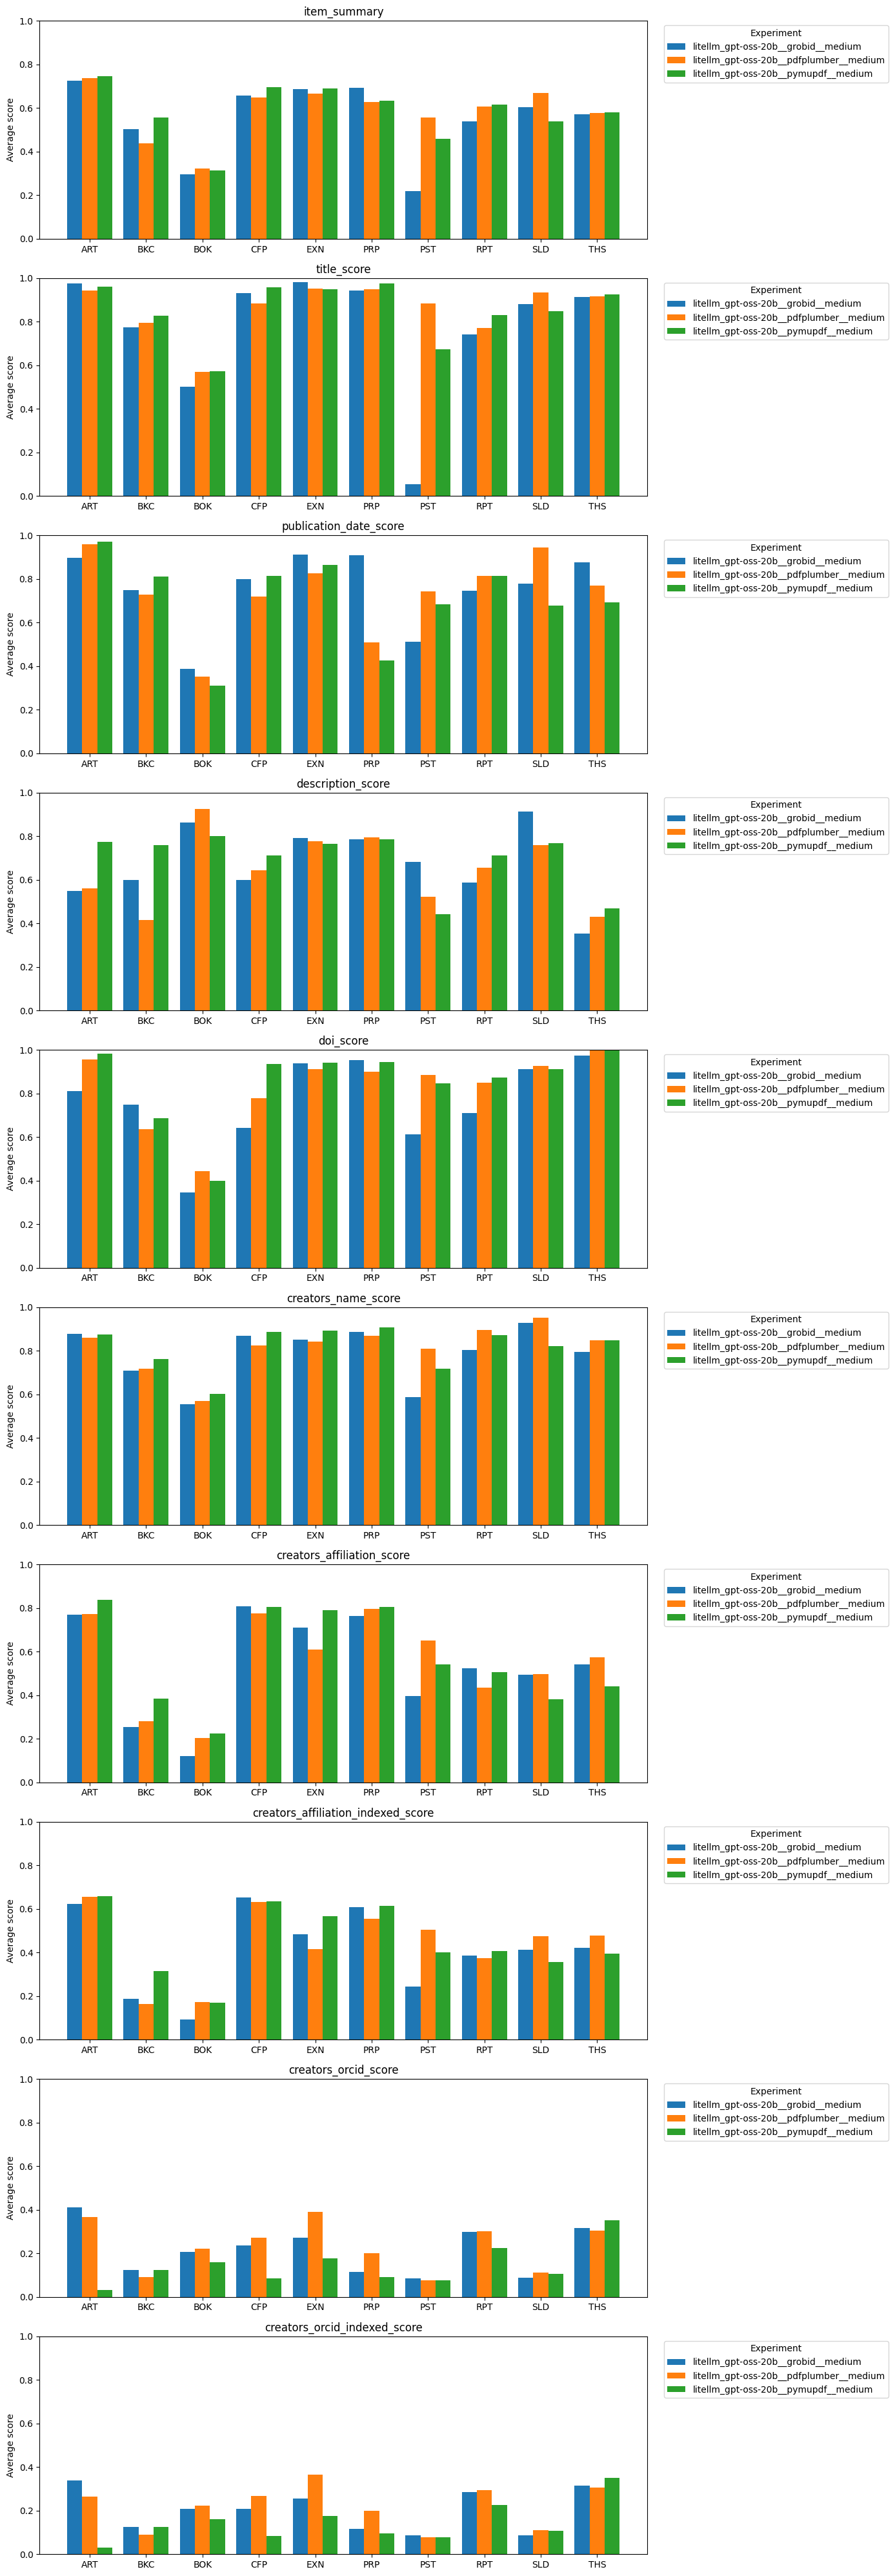

In [7]:
# remove duplicate fields while preserving order
score_order = [
    "item_summary",
    "title_score",
    "publication_date_score",
    "description_score",
    "doi_score",
    "creators_name_score",
    "creators_affiliation_score",
    "creators_affiliation_indexed_score",
    "creators_orcid_score",
    "creators_orcid_indexed_score",
]

score_order = list(dict.fromkeys(score_order))
score_order = [field for field in score_order if field in averages_by_experiment.columns]

# Add category column to the dataframe and get list of available categories
df["category"] = df["dataset_item"].str.split("_").str[0]
categories = sorted(df["category"].dropna().unique())


score_by_category = (
    df
    .groupby(["category", "experiment"])[score_order]
    .mean()
)

fig, axes = plt.subplots(
    len(score_order),
    1,
    figsize=(14, 4 * len(score_order)),
)

if len(score_order) == 1:
    axes = [axes]

for ax, field in zip(axes, score_order):
    plot_data = (
        score_by_category[field]
        .unstack()
        .reindex(categories)
        .copy()
    )

    experiments = list(plot_data.columns)
    x = np.arange(len(categories))
    width = 0.8 / len(experiments)

    for i, experiment in enumerate(experiments):
        ax.bar(
            x + i * width,
            plot_data[experiment].to_numpy(),
            width,
            label=experiment,
        )

    ax.set_xticks(
        x + width * (len(experiments) - 1) / 2
    )
    ax.set_xticklabels(categories)
    ax.set_ylabel("Average score")
    ax.set_title(field)
    ax.set_ylim(0, 1)
    ax.legend(
        title="Experiment",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

plt.tight_layout()
plt.show()

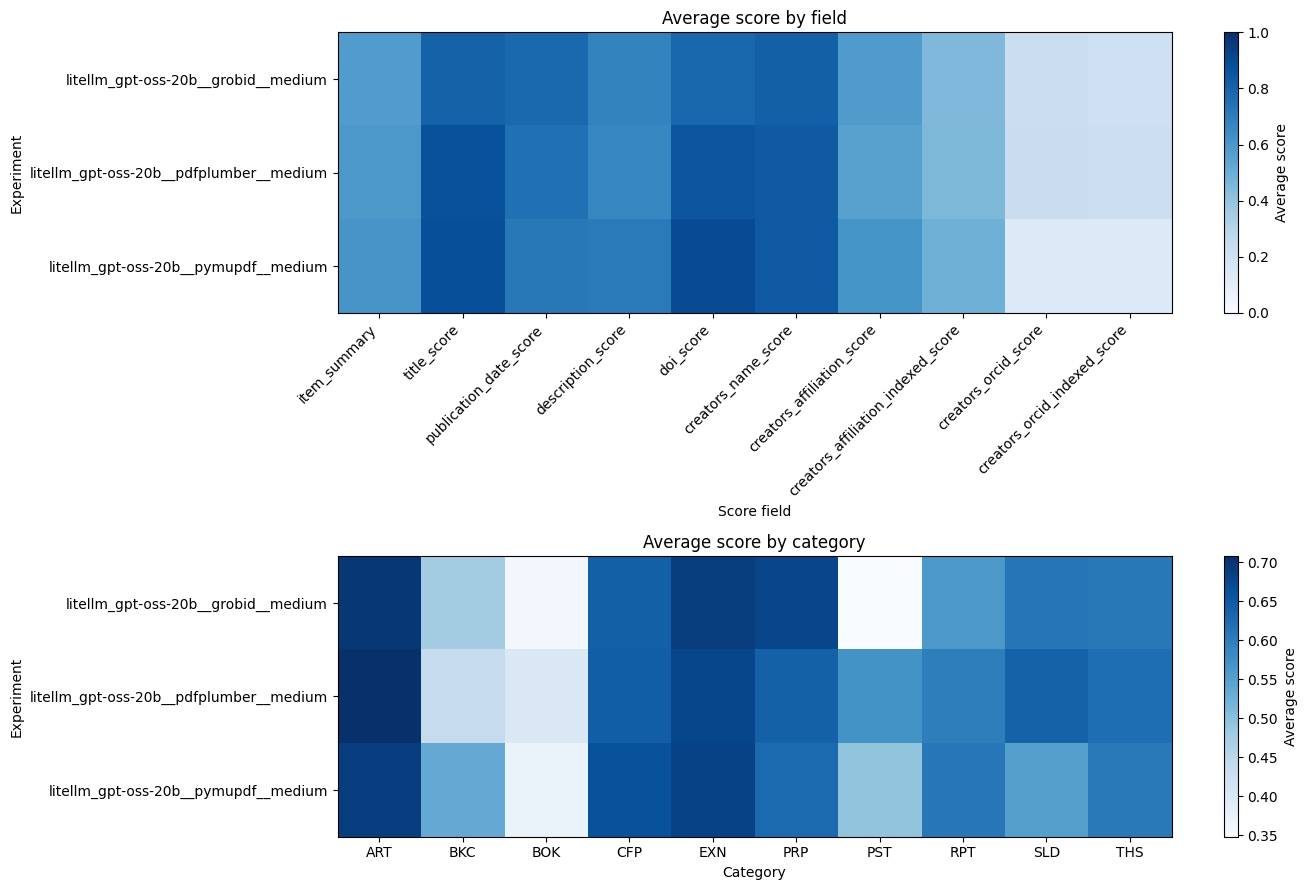

In [8]:

# Overall score by category
df["overall_score"] = df[score_order].mean(axis=1)

heatmap_fields = averages_by_experiment[score_order]

heatmap_categories = (
    df.groupby(["experiment", "category"])["overall_score"]
      .mean()
      .unstack()
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
)


# Experiments with fields

im1 = axes[0].imshow(
    heatmap_fields,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=1,
)

axes[0].set_xticks(range(len(heatmap_fields.columns)))
axes[0].set_xticklabels(
    heatmap_fields.columns,
    rotation=45,
    ha="right",
)

axes[0].set_yticks(range(len(heatmap_fields.index)))
axes[0].set_yticklabels(heatmap_fields.index)

axes[0].set_title("Average score by field")
axes[0].set_xlabel("Score field")
axes[0].set_ylabel("Experiment")

fig.colorbar(im1, ax=axes[0], label="Average score")


# Experiments with Categories

# Use the range of categories, because the difference is not distinguishable enough from 0-1
category_min = heatmap_categories.min().min()
category_max = heatmap_categories.max().max()

im2 = axes[1].imshow(
    heatmap_categories,
    aspect="auto",
    cmap="Blues",
    vmin=category_min,
    vmax=category_max,
)

axes[1].set_xticks(range(len(heatmap_categories.columns)))
axes[1].set_xticklabels(heatmap_categories.columns)

axes[1].set_yticks(range(len(heatmap_categories.index)))
axes[1].set_yticklabels(heatmap_categories.index)

axes[1].set_title("Average score by category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Experiment")

fig.colorbar(
    im2,
    ax=axes[1],
    label="Average score",
)

plt.tight_layout()
plt.show()

#### Standard deviation of latency per experiment 

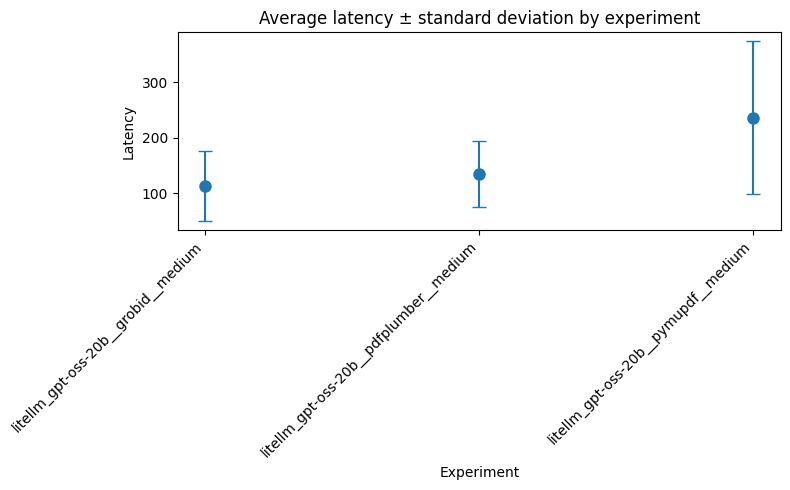

In [9]:

latency_stats = (
    df.groupby("experiment")["latency"]
    .agg(["mean", "std"])
)

x = np.arange(len(latency_stats))

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    latency_stats["mean"].to_numpy(),
    yerr=latency_stats["std"].to_numpy(),
    fmt="o",
    capsize=5,
    markersize=8,
)

plt.xticks(
    x,
    latency_stats.index,
    rotation=45,
    ha="right",
)

plt.xlabel("Experiment")
plt.ylabel("Latency")
plt.title("Average latency ± standard deviation by experiment")

plt.tight_layout()
plt.show()

#### Scores per experiment per category

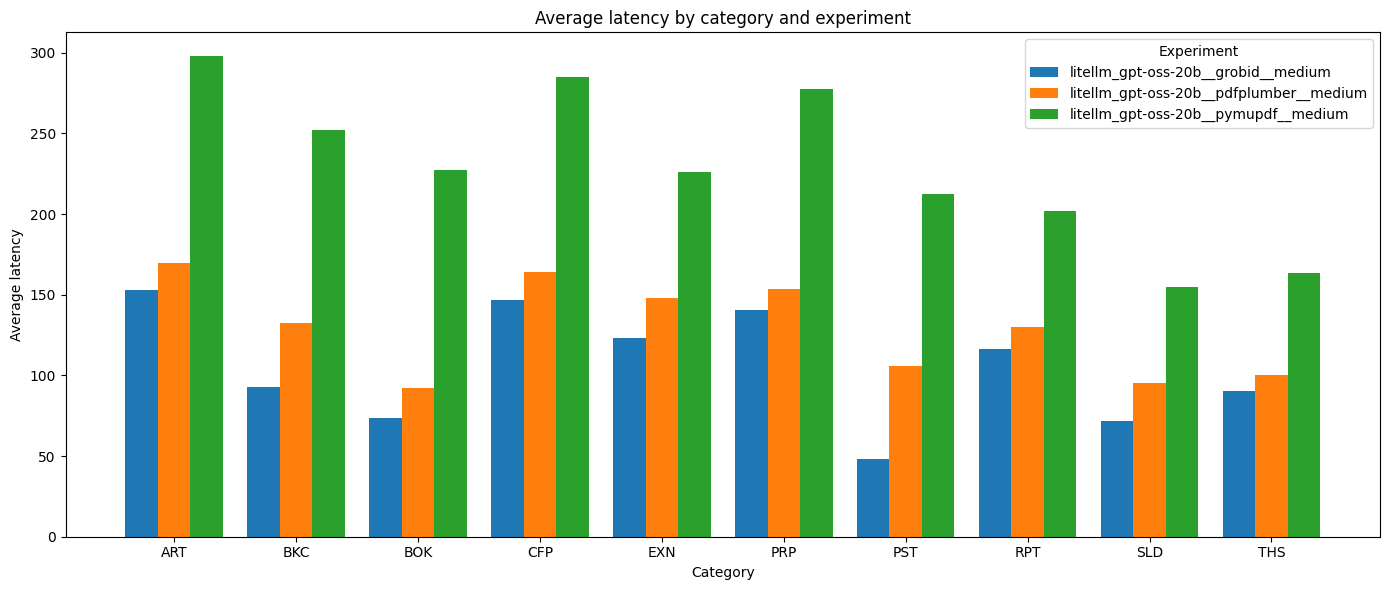

In [10]:


# Extract category from dataset_item
df["category"] = df["dataset_item"].str.split("_").str[0]

#  Average latency by category and experiment
latency_by_category = (
    df
    .groupby(["category", "experiment"])["latency"]
    .mean()
    .unstack()
)


# Plot
categories = latency_by_category.index
experiments = latency_by_category.columns

x = np.arange(len(categories))

# Width of each bar
width = 0.8 / len(experiments)

fig, ax = plt.subplots(figsize=(14, 6))

for i, experiment in enumerate(experiments):
    ax.bar(
        x + i * width,
        latency_by_category[experiment],
        width,
        label=experiment,
    )

# Center the category labels underneath the group of bars
ax.set_xticks(
    x + width * (len(experiments) - 1) / 2
)

ax.set_xticklabels(categories)

ax.set_xlabel("Category")
ax.set_ylabel("Average latency")
ax.set_title("Average latency by category and experiment")

ax.legend(title="Experiment")

plt.tight_layout()
plt.show()